In [22]:
import sys
import os

# Add project root to path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project Root:", project_root)

Project Root: d:\S62_0226_AcademicPulse_DSML_StudentRiskAndBurnoutAnalysis


In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from src.ml_features import create_ml_features
from src.ml_models import StudentRiskDetector

In [24]:
df = pd.read_csv("../data/raw/student_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (500, 14)


,student_id,attendance,exam1,exam2,exam3,exam4,performance_trend,study_hours_per_week,sleep_hours_per_night,avg_assignment_delay_days,engagement_score,actual_risk,avg_exam_score,exam_volatility
0,STU0001,82.9,74.4,81.6,81.4,85.0,stable,15.4,6.7,0.2,7.5,Low,80.600,4.451217
1,STU0002,59.1,53.1,53.7,52.2,52.4,stable,5.0,6.6,0.7,8.2,High,52.850,0.685565
2,STU0003,86.7,66.6,74.3,71.0,66.4,stable,11.8,7.3,0.7,8.6,Low,69.575,3.798574
3,STU0004,88.1,51.0,59.9,61.2,49.7,declining,7.3,8.7,0.4,5.9,Medium,55.450,5.936610
4,STU0005,58.6,83.3,86.9,88.9,90.2,improving,18.3,6.6,0.1,7.7,Low,87.325,3.007075


In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 500 non-null    object 
 1   attendance                 500 non-null    float64
 2   exam1                      500 non-null    float64
 3   exam2                      500 non-null    float64
 4   exam3                      500 non-null    float64
 5   exam4                      500 non-null    float64
 6   performance_trend          500 non-null    object 
 7   study_hours_per_week       500 non-null    float64
 8   sleep_hours_per_night      500 non-null    float64
 9   avg_assignment_delay_days  500 non-null    float64
 10  engagement_score           500 non-null    float64
 11  actual_risk                500 non-null    object 
 12  avg_exam_score             500 non-null    float64
 13  exam_volatility            500 non-null    float64

,attendance,exam1,exam2,exam3,exam4,study_hours_per_week,sleep_hours_per_night,avg_assignment_delay_days,engagement_score,avg_exam_score,exam_volatility
count,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,84.25300,74.896000,75.366400,75.32720,75.173200,20.542400,7.361200,0.968400,6.902400,75.190700,4.804765
std,13.33973,11.398145,11.424822,11.85334,12.629663,7.985235,1.401922,0.991912,1.937095,10.945166,2.000708
min,41.30000,45.700000,41.700000,37.50000,34.000000,5.000000,4.000000,0.000000,1.000000,41.400000,0.000000
25%,75.17500,66.600000,67.375000,68.20000,66.500000,15.000000,6.400000,0.300000,5.700000,67.400000,3.402817
50%,87.10000,74.950000,75.200000,75.70000,75.500000,20.300000,7.300000,0.600000,6.900000,74.625000,4.751491
75%,95.82500,82.450000,83.400000,83.30000,83.825000,26.125000,8.325000,1.400000,8.400000,83.262500,6.112529
max,100.00000,100.000000,100.000000,100.00000,100.000000,40.000000,11.600000,5.900000,10.000000,100.000000,12.259554


In [26]:
df = create_ml_features(df)

df.head()

,student_id,attendance,exam1,exam2,exam3,exam4,performance_trend,study_hours_per_week,sleep_hours_per_night,avg_assignment_delay_days,engagement_score,actual_risk,avg_exam_score,exam_volatility,exam_trend,sleep_risk,study_risk,attendance_risk,delay_risk,engagement_risk,behavioral_risk_score
0,STU0001,82.9,74.4,81.6,81.4,85.0,stable,15.4,6.7,0.2,7.5,Low,80.600,4.451217,10.6,0,0,0,0,0,0
1,STU0002,59.1,53.1,53.7,52.2,52.4,stable,5.0,6.6,0.7,8.2,High,52.850,0.685565,-0.7,0,1,1,0,0,2
2,STU0003,86.7,66.6,74.3,71.0,66.4,stable,11.8,7.3,0.7,8.6,Low,69.575,3.798574,-0.2,0,0,0,0,0,0
3,STU0004,88.1,51.0,59.9,61.2,49.7,declining,7.3,8.7,0.4,5.9,Medium,55.450,5.936610,-1.3,0,1,0,0,0,1
4,STU0005,58.6,83.3,86.9,88.9,90.2,improving,18.3,6.6,0.1,7.7,Low,87.325,3.007075,6.9,0,0,1,0,0,1


In [27]:
df.columns

Index(['student_id', 'attendance', 'exam1', 'exam2', 'exam3', 'exam4',
       'performance_trend', 'study_hours_per_week', 'sleep_hours_per_night',
       'avg_assignment_delay_days', 'engagement_score', 'actual_risk',
       'avg_exam_score', 'exam_volatility', 'exam_trend', 'sleep_risk',
       'study_risk', 'attendance_risk', 'delay_risk', 'engagement_risk',
       'behavioral_risk_score'],
      dtype='object')

In [28]:
model = StudentRiskDetector(n_clusters=3, contamination=0.1)

In [36]:
import importlib
import src.ml_models

importlib.reload(src.ml_models)

from src.ml_models import StudentRiskDetector

In [37]:
model = StudentRiskDetector()

In [38]:
model.fit(df)

d:\claudiajerome\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [39]:
df_pred = model.predict(df)

df_pred.head()

,student_id,attendance,exam1,exam2,exam3,exam4,performance_trend,study_hours_per_week,sleep_hours_per_night,avg_assignment_delay_days,engagement_score,actual_risk,avg_exam_score,exam_volatility,exam_trend,sleep_risk,study_risk,attendance_risk,delay_risk,engagement_risk,behavioral_risk_score,cluster,ml_risk_level,burnout_score,academic_risk_score,anomaly
0,STU0001,82.9,74.4,81.6,81.4,85.0,stable,15.4,6.7,0.2,7.5,Low,80.600,4.451217,10.6,0,0,0,0,0,0,0,Low,37.598447,11.640,0
1,STU0002,59.1,53.1,53.7,52.2,52.4,stable,5.0,6.6,0.7,8.2,High,52.850,0.685565,-0.7,0,1,1,0,0,2,1,Medium,75.534621,44.290,1
2,STU0003,86.7,66.6,74.3,71.0,66.4,stable,11.8,7.3,0.7,8.6,Low,69.575,3.798574,-0.2,0,0,0,0,0,0,0,Low,31.702251,18.255,0
3,STU0004,88.1,51.0,59.9,61.2,49.7,declining,7.3,8.7,0.4,5.9,Medium,55.450,5.936610,-1.3,0,1,0,0,0,1,1,Medium,44.277214,34.730,0
4,STU0005,58.6,83.3,86.9,88.9,90.2,improving,18.3,6.6,0.1,7.7,Low,87.325,3.007075,6.9,0,0,1,0,0,1,1,Medium,52.305282,15.605,0


In [40]:
df_pred.columns

Index(['student_id', 'attendance', 'exam1', 'exam2', 'exam3', 'exam4',
       'performance_trend', 'study_hours_per_week', 'sleep_hours_per_night',
       'avg_assignment_delay_days', 'engagement_score', 'actual_risk',
       'avg_exam_score', 'exam_volatility', 'exam_trend', 'sleep_risk',
       'study_risk', 'attendance_risk', 'delay_risk', 'engagement_risk',
       'behavioral_risk_score', 'cluster', 'ml_risk_level', 'burnout_score',
       'academic_risk_score', 'anomaly'],
      dtype='object')

In [41]:
df_pred["ml_risk_level"].value_counts()

ml_risk_level
Low       230
High      146
Medium    124
Name: count, dtype: int64

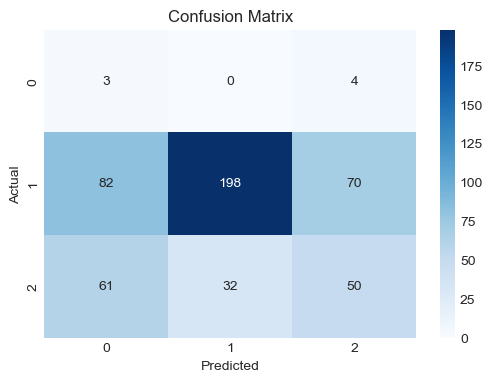

In [42]:
cm = confusion_matrix(df_pred["actual_risk"], df_pred["ml_risk_level"])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [43]:
print(classification_report(df_pred["actual_risk"], df_pred["ml_risk_level"]))

              precision    recall  f1-score   support

        High       0.02      0.43      0.04         7
         Low       0.86      0.57      0.68       350
      Medium       0.40      0.35      0.37       143

    accuracy                           0.50       500
   macro avg       0.43      0.45      0.37       500
weighted avg       0.72      0.50      0.59       500



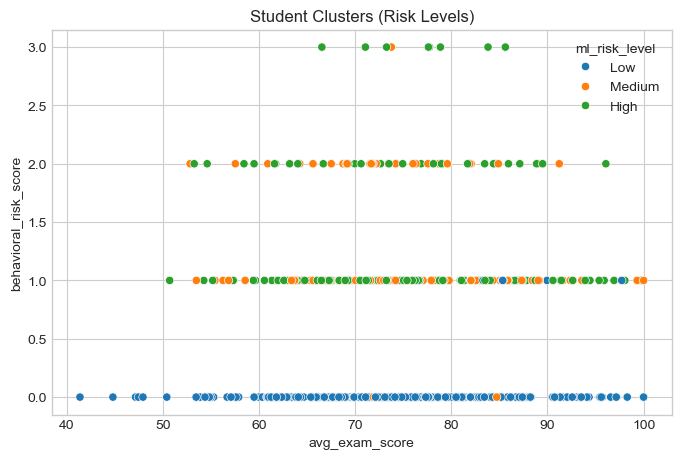

In [44]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_pred,
    x="avg_exam_score",
    y="behavioral_risk_score",
    hue="ml_risk_level",
)

plt.title("Student Clusters (Risk Levels)")
plt.show()

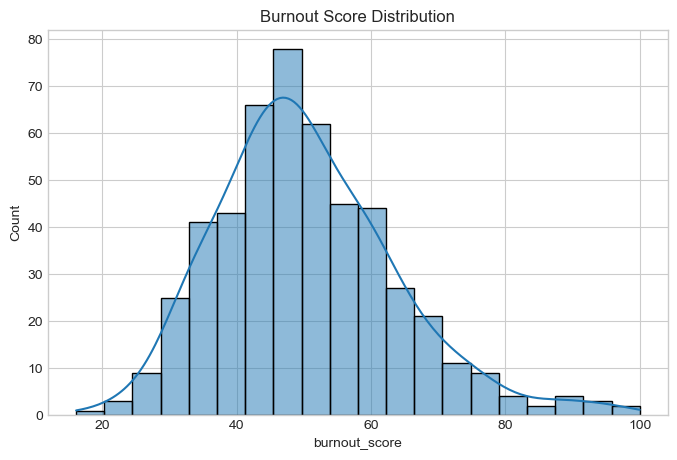

In [45]:
plt.figure(figsize=(8, 5))

sns.histplot(df_pred["burnout_score"], kde=True)

plt.title("Burnout Score Distribution")
plt.show()

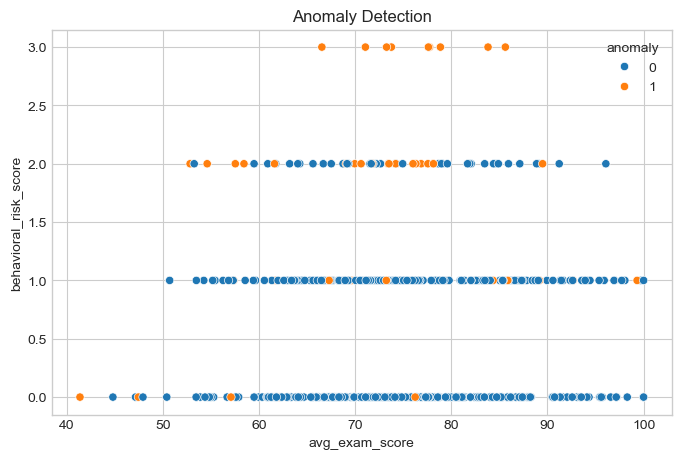

In [46]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_pred,
    x="avg_exam_score",
    y="behavioral_risk_score",
    hue="anomaly",
)

plt.title("Anomaly Detection")
plt.show()

In [47]:
os.makedirs("../models", exist_ok=True)

model.save_model("../models/student_risk_detector.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅


In [48]:
os.makedirs("../data/processed", exist_ok=True)

df_pred.to_csv("../data/processed/ml_predictions.csv", index=False)

print("Predictions saved successfully ✅")

Predictions saved successfully ✅


In [49]:
df_pred.sample(5)

,student_id,attendance,exam1,exam2,exam3,exam4,performance_trend,study_hours_per_week,sleep_hours_per_night,avg_assignment_delay_days,engagement_score,actual_risk,avg_exam_score,exam_volatility,exam_trend,sleep_risk,study_risk,attendance_risk,delay_risk,engagement_risk,behavioral_risk_score,cluster,ml_risk_level,burnout_score,academic_risk_score,anomaly
3,STU0004,88.1,51.0,59.9,61.2,49.7,declining,7.3,8.7,0.4,5.9,Medium,55.450,5.936610,-1.3,0,1,0,0,0,1,1,Medium,44.277214,34.730,0
363,STU0364,99.3,90.1,89.7,84.6,98.6,improving,13.3,7.3,0.4,8.6,Low,90.750,5.801437,8.5,0,0,0,0,0,0,0,Low,45.972418,5.550,0
416,STU0417,89.4,89.0,87.5,89.8,99.5,improving,28.8,4.9,0.3,9.4,Low,91.450,5.450688,10.5,1,0,0,0,0,1,2,High,58.834171,13.130,0
57,STU0058,91.2,99.9,87.3,92.0,97.4,improving,26.7,6.2,2.9,2.4,Medium,94.150,5.632347,-2.5,0,0,0,0,1,1,2,High,64.214994,11.510,0
391,STU0392,61.9,69.1,74.2,73.0,69.2,improving,19.5,7.4,1.2,9.0,Low,71.375,2.615817,0.1,0,0,1,0,0,1,2,High,46.111902,25.175,0
